In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv('train.csv')

# split data into features and target
x = df.drop(columns=['Yearly Amount Spent'], axis=1)
y = df['Yearly Amount Spent']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.80, test_size=0.2, random_state=42)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

# evaluate model
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

Model Coefficients: [26.01793917 39.04734305  0.43619601 61.11897199]
Model Intercept: -1063.2681824835586
Mean Absolute Error: 7.486880389502434
Mean Squared Error: 90.71082755715632
Root Mean Squared Error: 9.524223199671264
R2 Score: 0.9774584407395603


In [ ]:
# Predicting each Y value
df['Pred Y']=model.predict(x)
df.head()

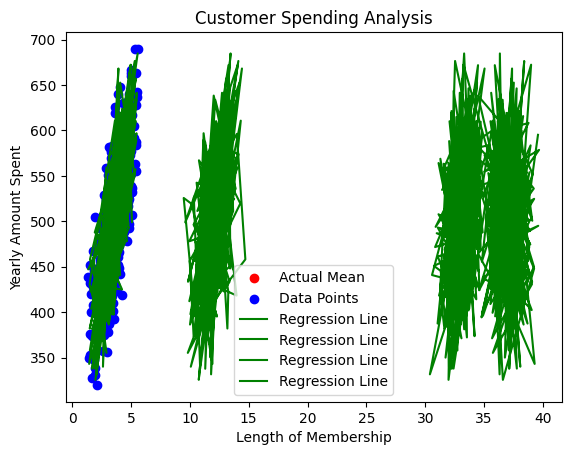

In [5]:
plt.scatter(df['Length of Membership'].mean(), df['Yearly Amount Spent'].mean(), color='red', label='Actual Mean')
plt.scatter(df['Length of Membership'], df['Yearly Amount Spent'], color='blue', label='Data Points')
plt.plot(x, model.predict(x), color='green', label='Regression Line')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.title('Customer Spending Analysis')
plt.legend()
plt.show()